# 2D spectrum

In [18]:
import numpy as np

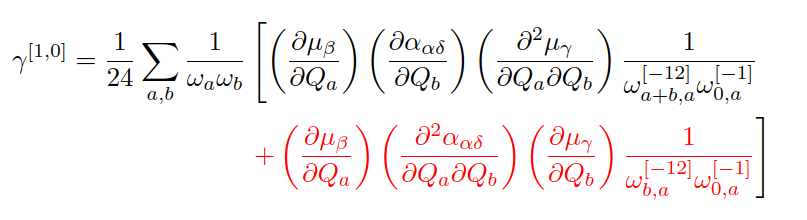

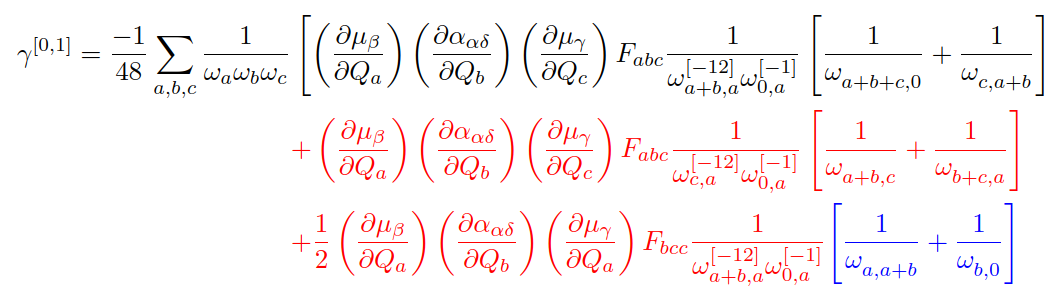

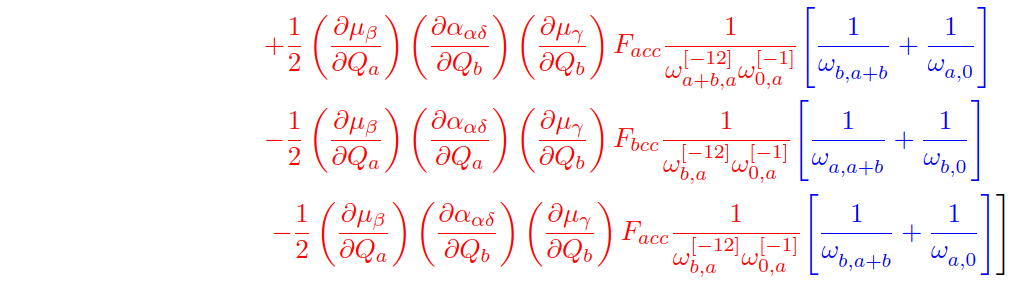

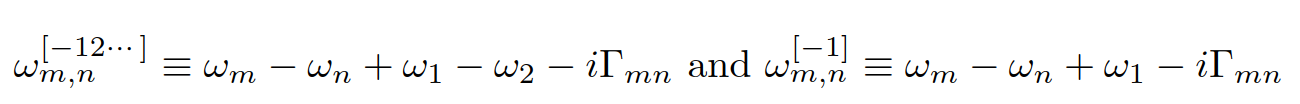

### 1. Orientational averaging (over $\alpha, \beta, \gamma, \delta$)

In [19]:
# one term function with given pattern of derivatives
def avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha):
    f = dmu[len(todo[0])-1][(beta,) + todo[0]]
    s = dalpha[len(todo[1])-1][(alpha, delta,) + todo[1]]
    t = dmu[len(todo[2])-1][(gamma,) + todo[2]]

    return f * s * t

# average over given suscept_tensor_comp
def orientavr_total(suscept_tensor_comp, todo, dmu, dalpha):
    ders_avrg = []
    
    for alpha in suscept_tensor_comp[0]:
        for beta in suscept_tensor_comp[1]:
            for gamma in suscept_tensor_comp[2]:
                for delta in suscept_tensor_comp[3]:
                    
                    ders_avrg.append(avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha))
                    
    avrgders = sum(ders_avrg) / len(ders_avrg)
    return avrgders

### 2D-IR intensities

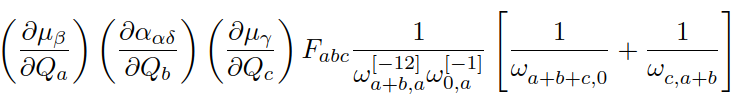

In [236]:
# DERIVATIVES SETUP

# deriv_mu_first[0, i] --- delta(mu_x)/delta(Q_i)
# deriv_mu_first[1, i] --- delta(mu_y)/delta(Q_i)
deriv_mu_first = np.array([14.1]*3*3).reshape(3, 3)

# deriv_mu_second[0, i, j] --- delta(mu_x)/delta(Q_i)/delta(Q_j)
# deriv_mu_second[1, i, j] --- delta(mu_y)/delta(Q_i)/delta(Q_j)
deriv_mu_second = np.array([22.1]*3*3*3).reshape(3, 3, 3)

deriv_mu = [deriv_mu_first, deriv_mu_second]

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
deriv_alpha_first = np.array([-7.1]*3*3*3).reshape(3, 3, 3)

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
# deriv_alpha_second[0, 1, i, j] --- delta(alpha_xy)/delta(Q_i)/delta(Q_j)
deriv_alpha_second = np.array([13.1]*3*3*3*3).reshape(3, 3, 3, 3)

deriv_alpha = [deriv_alpha_first, deriv_alpha_second]

suscept_tensor_comps = [[2], [2], [2], [2]]

Gamma = 0.0001
Delta = {'00': 10, '11': 30, '01': 70, '12': 80, '012': 20, '000': 20}

w = {0: 1775.31595735, 1: 4176.50069324, 2: 4267.11889757}

F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 170.24
F[0, 1, 1] = 170.24

w2_s = 10
w2_e = 20
w1_s = 10
w1_e = 20
Nfreqs1 = 6
Nfreqs2 = 6

# w2_s = 4
# w2_e = 9
# w1_s = 1
# w1_e = 5
# Nfreqs = 5

# w1, w2 = np.linspace(5, 10, 5), np.linspace(5, 10, 5)
# w1, w2 = np.array([4100, 4220]), np.array([4170, 4270])
w1, w2 = np.linspace(4100, 5220, 300), np.linspace(4170, 5270, 300)

ranges = (w1_s, w1_e, w2_s, w2_e, Nfreqs1, Nfreqs2)

#data = [[], [], w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]
# data = [w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]
data = [w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]

### 2. Resonances

In [237]:
#
def ResonanceTerm(w1, w2, sbscrpts_comma, superscript, w, Gamma_mn, Delta):
    # ((a, b,), (a))

    if len(superscript)==1:
        # print(W_comb(sbscrpts_comma[0], w, Delta),  W_comb(sbscrpts_comma[1], w, Delta), w1)
        return W_comb(sbscrpts_comma[0], w, Delta) - W_comb(sbscrpts_comma[1], w, Delta) + w1 - 1j*Gamma_mn
    
    else:
        # print(W_comb(sbscrpts_comma[0], w, Delta),  W_comb(sbscrpts_comma[1], w, Delta), w1, w2)
        # print('inside', W_comb(sbscrpts_comma[0], w, Delta) - W_comb(sbscrpts_comma[1], w, Delta) + w1 - w2 - 1j*Gamma_mn)
        return W_comb(sbscrpts_comma[0], w, Delta) - W_comb(sbscrpts_comma[1], w, Delta) + w1 - w2 - 1j*Gamma_mn
        
    
def W_comb(sbscrpt, w, Delta):
    # (a, b,)

    if len(sbscrpt)==1:
        w_m = w[sbscrpt[0]]
        
    else:
        w_m = 0
        keystr = ''
        for i in sbscrpt:
            w_m += w[i]
            keystr += str(i)
        # print(keystr)
        w_m -= Delta[keystr]

    return w_m

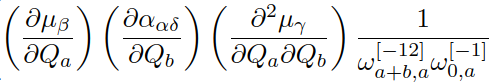

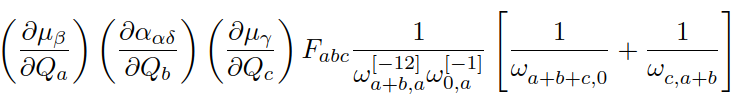

In [238]:
a, b, c = 0, 1, 1
def anhTerm(w1, w2, NMindices=(a, b, c), todo=[(a,), (b,), (c)], resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
            fractions=[((a, b, c), (0,)), ((c,), (a, b,)),],
            data=data):
    
    w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data 
    w_0 = 0.
    
    avrgders = orientavr_total(suscept_tensor_comps, todo, deriv_mu, deriv_alpha)
    
    resonance1 = ResonanceTerm(w1, w2, resonances[0], resonances[0][-1], w, Gamma, Delta)
    resonance2 = ResonanceTerm(w1, w2, resonances[1], resonances[1][-1], w, Gamma, Delta)
    # print('avrg', avrgders)
    # print('r1', resonance1)
    # print('r2', resonance2)
    
    if fractions is not None:
        extra = F[a, b, c] * (1/(W_comb(fractions[0][0], w, Delta) - W_comb(fractions[0][1], w, Delta)) 
                              + 1/(W_comb(fractions[1][0], w, Delta) - W_comb(fractions[1][1], w, Delta)) )
        # print(extra)
    else:
        extra = 1
    # extra = 1
    return avrgders * (1/resonance1) * (1/resonance2) * extra

In [240]:
np.set_printoptions(linewidth=100000)
# anhTerm(NMindices=(a, b, c), 
#             #todolist={0:todo0, 1:todo1}, 
#             todo=[(a,), (b,), (a, b,)],
#             resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
#             fractions=[((a, b, c), (0,)), ((c,), (a, b,)),], 
#             data=data)
NMindices=(a, b, c)
#todolist={0:todo0, 1:todo1}
todo=[(a,), (b,), (a, b,)]
resonances=[ [(a, b,), (a,), (-1, 2,)], [(0,), (a,), (-1,)] ]
fractions=[((a, b, c), (0,)), ((c,), (a, b,)),]
# data=data
sbscrpts = ((a, b,), (a))

# Delta['01']=0
Delta = {'00': 10, '11': 30, '01': 70, '12': 80, '012': 20, '000': 20, '011': 20}
# Delta = {'00': 70, '11': 30, '01': 10, '12': 80, '012': 120}

[(0, 1), (0,)]
{0: 1775.31595735, 1: 4176.50069324, 2: 4267.11889757} [4100.         4103.7458194  4107.4916388  4111.23745819 4114.98327759 4118.72909699 4122.47491639 4126.22073579 4129.96655518 4133.71237458 4137.45819398 4141.20401338 4144.94983278 4148.69565217 4152.44147157 4156.18729097 4159.93311037 4163.67892977 4167.42474916 4171.17056856 4174.91638796 4178.66220736 4182.40802676 4186.15384615 4189.89966555 4193.64548495 4197.39130435 4201.13712375 4204.88294314 4208.62876254 4212.37458194 4216.12040134 4219.86622074 4223.61204013 4227.35785953 4231.10367893 4234.84949833 4238.59531773 4242.34113712 4246.08695652 4249.83277592 4253.57859532 4257.32441472 4261.07023411 4264.81605351 4268.56187291 4272.30769231 4276.05351171 4279.7993311  4283.5451505  4287.2909699  4291.0367893  4294.7826087  4298.52842809 4302.27424749 4306.02006689 4309.76588629 4313.51170569 4317.25752508 4321.00334448 4324.74916388 4328.49498328 4332.24080268 4335.98662207 4339.73244147 4343.47826087 4347.

In [ ]:
print(resonances[0][:2])
print(w, w1, w2)
# aaa = np.vectorize(ResonanceTerm,excluded=['sbscrpts_comma', 'superscript', 'w', 'Gamma', 'Delta'])
aaa = ResonanceTerm(w1, w2, sbscrpts_comma=[(a, b,), (a,)], superscript=(-1, 2,), w=w, Gamma_mn=1, Delta=Delta)
print('outside')
print(aaa, aaa.shape)

xx, yy = np.meshgrid(w1, w2)
print('-----------------------------------------------------')

print(resonances[0][:2])
print(w, w1, w2)
aaa = np.vectorize(ResonanceTerm,excluded=['sbscrpts_comma', 'superscript', 'w', 'Gamma', 'Delta'])
aaa = ResonanceTerm(xx, yy, sbscrpts_comma=[(a, b,), (a,)], superscript=(-1, 2,), w=w, Gamma_mn=1, Delta=Delta)
print('outside')
print(aaa, aaa.shape)

In [242]:
np.set_printoptions(linewidth=100000)

xx, yy = np.meshgrid(w1, w2)
Gamma = 1
data = [w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]

import time
# get the start time
st = time.time()

rr = np.vectorize(anhTerm, excluded=['NMindices', 'todo', 'resonances', 'fractions', 'data'])(xx, yy, NMindices=(a, b, c), 
            #todolist={0:todo0, 1:todo1}, 
            todo=[(a,), (b,), (a, b,)],
            resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
            fractions=[((a, b, c), (0,)), ((c,), (a, b,)),], 
            data=data)
# get the end time
et = time.time()

# get the execution time
elapsed_time = et - st
print('Execution time:', elapsed_time, 'seconds')
# print(rr.T)

print('-------------------------------------')

st2 = time.time()

rr2 = anhTerm(xx, yy, NMindices=(a, b, c), 
            #todolist={0:todo0, 1:todo1}, 
            todo=[(a,), (b,), (a, b,)],
            resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
            fractions=[((a, b, c), (0,)), ((c,), (a, b,)),], 
            data=data)
# get the end time
et2 = time.time()

# get the execution time
elapsed_time2 = et2 - st2
print('Execution time:', elapsed_time2, 'seconds')
# print(rr2.T)

print('-------------------------------------')

st1 = time.time()
allff = []
for i in w1:
    for j in w2:
        allff.append(anhTerm(i, j, NMindices=(a, b, c), 
                    #todolist={0:todo0, 1:todo1}, 
                    todo=[(a,), (b,), (a, b,)],
                    resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
                    fractions=[((a, b, c), (0,)), ((c,), (a, b,)),], 
                    data=data))
# get the end time
et1 = time.time()

# get the execution time
elapsed_time1 = et1 - st1
print('Execution time:', elapsed_time1, 'seconds')
# print(np.array(allff).reshape(3,3))


Execution time: 0.9347293376922607 seconds
-------------------------------------
Execution time: 0.005610942840576172 seconds
-------------------------------------
Execution time: 1.281045913696289 seconds


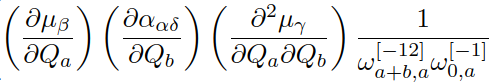

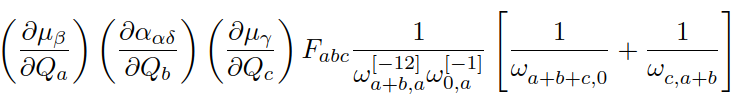

In [ ]:
todo_el0 = [(a,), (b,), (a, b,)]
todo_el1 = [(a,), (a, b,), (b,)]
resonances_el0 = [ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ]
resonances_el1 = [ ((b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ]
fractions0, fractions1 = None, None

todolist = {0: (todo_el0, resonances_el0, fractions0), 1: (todo_el1, resonances_el1, fractions1)}

In [ ]:
def el_anhALLab(data, settings
                , todolist
               ):
    """
    """
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w_0 = 0.
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    if settings['test']:
        w = {0: 100, 1:200}
        totalres = 0.
    
    # itteration over normal modes/states
    for a in range(len(w)):
        for b in range(len(w)):
            
            if settings['test']:
                firstfrac = 1
            else:
                firstfrac = 1/ w[a] / w[b]
            
            terms_all = {}
            
            for k in todolist:
                terms_all[k] = anhTerm(w1, w2, NMindices=(a, b), 
                                    todo=todolist[k][0],
                                    resonances=todolist[k][1],
                                    fractions=todolist[k][2], 
                                    data=data)
            
#             # term 1 --------------------------
#             term1 = anhTerm(w1, w2, NMindices=(a, b), 
#                             todo=[(a,), (b,), (a, b,)],
#                             resonances=[ ((a, b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
#                             fractions=None, 
#                             data=data)
            
#             # term 2 --------------------------
#             if settings['el_t2']:
                
#                 term2 = anhTerm(w1, w2, NMindices=(a, b), 
#                             #todolist={0:todo0, 1:todo1}, 
#                             todo=[(a,), (a, b,), (b,)],
#                             resonances=[ ((b,), (a,), (-1, 2,)), ((0,), (a,), (-1,)) ],
#                             fractions=None, 
#                             data=data)
                
#             else:
#                 term2 = 0. #np.zeros((w1.shape), dtype='complex128')
            
#             totalres += firstfrac * (term1 + term2)
            
            # not necessary, actually
            if not settings['el_t2']:
                terms_all[2] = 0.
            
            totalres += firstfrac * sum(terms_all.values())
            
    
    return totalres/24.

In [ ]:
def el_anhALLab(data, settings, todolist):
    """
    """
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w_0 = 0.
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    if settings['test']:
        w = {0: 100, 1:200}
        totalres = 0.
    
    # itteration over normal modes/states
    for a in range(len(w)):
        for b in range(len(w)):
            
            # testing
            if settings['test']:
                firstfrac = 1
            else:
                firstfrac = 1/ w[a] / w[b]
                        
            # get all terms for the sum
            terms_all = {}

            for k in todolist:
                terms_all[k] = anhTerm(w1, w2, NMindices=(a, b), 
                                    todo=todolist[k][0],
                                    resonances=todolist[k][1],
                                    fractions=todolist[k][2], 
                                    data=data)
            
            # not necessary, actually
            if not settings['el_t2']:
                terms_all[2] = 0.
            
            totalres += firstfrac * sum(terms_all.values())
            
    return totalres/24.

In [216]:
# w1, w1-w2
import math
import numpy as np


# electrical anharmonicity for all normal mode pairs
# @np.vectorize
def el_anhALLab(data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w_0 = 0.
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    if settings['test']:
        
        w = {0: 100, 1:200}
        totalres = 0.
    
    # itteration over normal modes/states
    for a in range(len(w)):
        for b in range(len(w)):
            
            if settings['test']:
                firstfrac = 1
            else:
                firstfrac = 1/ w[a] / w[b]
            
            # term 1 --------------------------
            resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
            resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
#             print('\nw1-w2')
#             print(w1-w2)
#             print('\nw1')
#             print(w1)
#             print('\nw2')
#             print(w2)
#             print('-----------------------------------')

            
            term1 = w1-w2+w[a]-w[b]
            # print('term1')
            # print(term1)
            # print('-----------------------------------')
#             todo1 = [(a,), (b,), (a, b,)]
#             avrgders = orientavr_total(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
#             # avrgders = 1
            
#             term1 = avrgders / resonance1_1 / resonance2_1
            
            if t2:
                # term 2 --------------------------
                resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
                resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

                todo2 = [(a,), (a, b,), (b,)]
                avrgders2 = orientavr_total(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                # avrgders2 = 1
                
                term2 = avrgders2 / resonance1_2 / resonance2_2
                # print('EL term2-term1', max(term2.flatten())-max(term1.flatten()))
                
            else:
                term2 = 0. #np.zeros((w1.shape), dtype='complex128')
            
            totalres += firstfrac * (term1 + term2)
    # print('totalres')
    # print(totalres)
    # print('-----------------------------------')
    return totalres#/24.

# 
def el_anh_ab(a, b, data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    firstfrac = 1/ w[a] / w[b]
    
    # term 1 --------------------------
    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
    resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
    
    # averaging
    todo1 = [(a,), (b,), (a, b,)]
    avrgders = orientavr_total(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
    avrgders = 1
    
    term1 = avrgders / resonance1_1 / resonance2_1
    
    if t2:
        # term 2 --------------------------
        resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
        resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

        # averaging
        todo2 = [(a,), (a, b,), (b,)]
        avrgders2 = orientavr_total(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
        avrgders2 = 1

        term2 = avrgders2 / resonance1_2 / resonance2_2
        # print('EL term2-term1', max(term2.flatten())-max(term1.flatten()))
        
    else:
        term2 = 0
            
    totalres += firstfrac * (term1+term2)
    
    return totalres/24. #* 10**5


def mech_anh(data, settings):
    on = settings['mech_on']
    t2 = settings['mech_t2']
    t3 = settings['mech_t3']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0
    
    # totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    totalres = 0.
    # totalres = []
    
    if not on:
        return totalres
    
    else:
    
        for a in range(len(w)):
            for b in range(len(w)):
                for c in range(len(w)):

                    firstfrac = 1 / w[a] / w[b] / w[c]

                    # term 1 -------------------------- 
                    fracs = 1 / ((w[a] + w[b] + w[c] - Delta['abc']) - w_0) + 1 / (w[c] - (w[a] + w[b] - Delta['ab']))

                    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                    resonance2_1 = w_0 - w[a] - Gamma * 1j

                    # averaging
                    todo1 = [(a,), (b,), (c,)]
                    avrgders = orientavr_total(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
                    avrgders = 1
                    
                    term1 = avrgders * fracs * F[a, b, c] / resonance1_1 / resonance2_1

                    if t2:
                        # term 2 -------------------------- 
                        fracs2 = 1 / ((w[a] + w[b] - Delta['ab']) - w[c]) + 1 / ((w[b] + w[c] - Delta['bc']) - w[a])

                        resonance1_2 = w[c] - w[a] - w1mw2 - Gamma * 1j
                        resonance2_2 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo2 = [(a,), (b,), (c,)]
                        avrgders2 = orientavr_total(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                        avrgders2 = 1
                        
                        term2 = avrgders2 * fracs2 * F[a, b, c] / resonance1_2 / resonance2_2
                        # print('MECH term2-term1', max(term2.flatten())-max(term1.flatten()))
                        
                    else:
                        term2 = 0.

                    if t3:
                        # term 3 -------------------------- 
                        fracs3 = 1 / (w[a] - (w[a] + w[b] - Delta['ab'])) + 1 / (w[b] - w_0)

                        resonance1_3 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                        resonance2_3 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo3 = [(a,), (b,), (a,)]
                        avrgders3 = orientavr_total(suscept_tensor_comps, todo3, deriv_mu, deriv_alpha)
                        avrgders3 = 1

                        term3 = avrgders3 * fracs3 * F[a, b, c] / resonance1_3 / resonance2_3
                        # print('MECH term3-term1', max(term3.flatten())-max(term1.flatten()))
                        
                    else:
                        term3 = 0.

                    totalres += firstfrac * (term1 + term2 + term3)
                    # totalres.append(firstfrac * (term1 + term2 + term3))

        return -totalres/48. #* 10**5


def spectrum(data, settings):
    w1mw2 = settings['w1mw2_axis']
    prt = settings['printing']
    
    # compute the third dimension at each point on the grid
    ELanh = el_anhALLab(data, settings)
    MECHanh = mech_anh(data, settings)
    
    Z = abs(ELanh + MECHanh)**2
    
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None
        
    return data[0], data[1], Z


%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

def plotspectrum(ranges, numbers, settings):
    # ALL PARAMETERS 
    w1_s, w1_e, w2_s, w2_e, Nfreqs1, Nfreqs2 = ranges
    w1, w2 = np.linspace(w1_s, w1_e, Nfreqs1), np.linspace(w2_s, w2_e, Nfreqs2)
    
    w1mw2=settings['w1mw2_axis']
    # w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = numbers
    
    xx, yy = np.meshgrid(w1, w2)
    numbers[0], numbers[1] = xx, yy
    
    # PLOTTING
    fig, ax = plt.subplots()
    fig.set_size_inches(11, 9)

    X, Y, Z = spectrum(numbers, settings)
    # Z = Z#*10**18
    print(Z)
    
    # print(numbers)
    xaxis = X
    ax.set_xlabel('w1', fontsize=18)

    if w1mw2:
        yaxis = X-Y
        ax.set_ylabel('w1-w2', fontsize=18)
    else:
        yaxis = Y
        ax.set_ylabel('w2', fontsize=18)
    
    cp = ax.contourf(xaxis, yaxis, Z)

    # ax.legend()
    # print(cp)
    # import matplotlib.colors as colors
    cp = ax.pcolormesh(Z, vmin=0, vmax=6400)
    # a = fig.axes(np.linspace(0, 6400, len(Z)))
    
    # colormap = plt.cm.cool 
    # Normalize using the min and max values in a
    # normalize = plt.Normalize(vmin=min(a), vmax=max(a))
    
    cb = fig.colorbar(cp)
    # cb = plt.colorbar(cbcb)
    
    # plt.grid()
    fig.set_tight_layout(True)

    ax.set_xticks(np.linspace(min(xaxis.flatten())-10, max(xaxis.flatten())+10, 25))
    ax.set_yticks(np.linspace(min(yaxis.flatten())-10, max(yaxis.flatten())+10, 25))
    
    ax.set_xlim(min(xaxis.flatten())-20, max(xaxis.flatten())+20)   
    ax.set_ylim(min(yaxis.flatten())-20, max(yaxis.flatten())+20)

    plt.xticks(rotation = 90)
    
    if not w1mw2 and settings['show_fundamentals']:
        for k, f in w.items():
            plt.axvline(x=f, color ='k', linewidth=0.5)
            plt.axhline(y=f, color ='k', linewidth=0.5)
    
    plt.show()

In [14]:
# DERIVATIVES SETUP

# deriv_mu_first[0, i] --- delta(mu_x)/delta(Q_i)
# deriv_mu_first[1, i] --- delta(mu_y)/delta(Q_i)
deriv_mu_first = np.array([14.1]*3*3).reshape(3, 3)

# deriv_mu_second[0, i, j] --- delta(mu_x)/delta(Q_i)/delta(Q_j)
# deriv_mu_second[1, i, j] --- delta(mu_y)/delta(Q_i)/delta(Q_j)
deriv_mu_second = np.array([22.1]*3*3*3).reshape(3, 3, 3)

deriv_mu = [deriv_mu_first, deriv_mu_second]

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
deriv_alpha_first = np.array([-7.1]*3*3*3).reshape(3, 3, 3)

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
# deriv_alpha_second[0, 1, i, j] --- delta(alpha_xy)/delta(Q_i)/delta(Q_j)
deriv_alpha_second = np.array([13.1]*3*3*3*3).reshape(3, 3, 3, 3)

deriv_alpha = [deriv_alpha_first, deriv_alpha_second]

suscept_tensor_comps = [[2], [2], [2], [2]]

Gamma = 0.0001
Delta = {'11': 70, '22': 30, '12': 70, '23': 80, '123': 120}

w = {0: 1775.31595735, 1: 4176.50069324, 2: 4267.11889757}

F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 170.24

w2_s = 10
w2_e = 20
w1_s = 10
w1_e = 20
Nfreqs1 = 6
Nfreqs2 = 6

# w2_s = 4
# w2_e = 9
# w1_s = 1
# w1_e = 5
# Nfreqs = 5


ranges = (w1_s, w1_e, w2_s, w2_e, Nfreqs1, Nfreqs2)
data = [[], [], w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]

NameError: name 'np' is not defined

[[   0.   64.  256.  576. 1024. 1600. 2304. 3136. 4096. 5184. 6400.]
 [  64.    0.   64.  256.  576. 1024. 1600. 2304. 3136. 4096. 5184.]
 [ 256.   64.    0.   64.  256.  576. 1024. 1600. 2304. 3136. 4096.]
 [ 576.  256.   64.    0.   64.  256.  576. 1024. 1600. 2304. 3136.]
 [1024.  576.  256.   64.    0.   64.  256.  576. 1024. 1600. 2304.]
 [1600. 1024.  576.  256.   64.    0.   64.  256.  576. 1024. 1600.]]


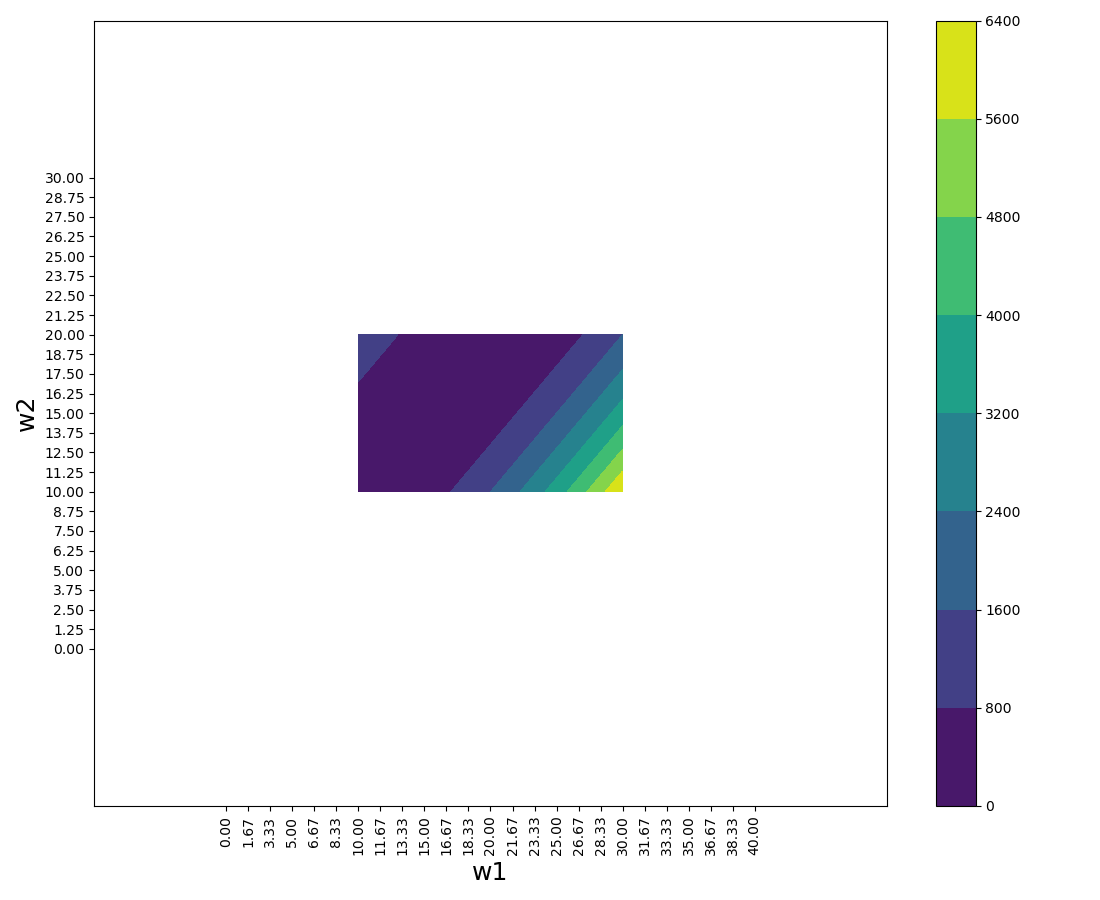

In [213]:
settings = {'el_t2':False, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True,
            'test':False}
plotspectrum(ranges, data, settings)

[[   0.   64.  256.  576. 1024. 1600.]
 [  64.    0.   64.  256.  576. 1024.]
 [ 256.   64.    0.   64.  256.  576.]
 [ 576.  256.   64.    0.   64.  256.]
 [1024.  576.  256.   64.    0.   64.]
 [1600. 1024.  576.  256.   64.    0.]]


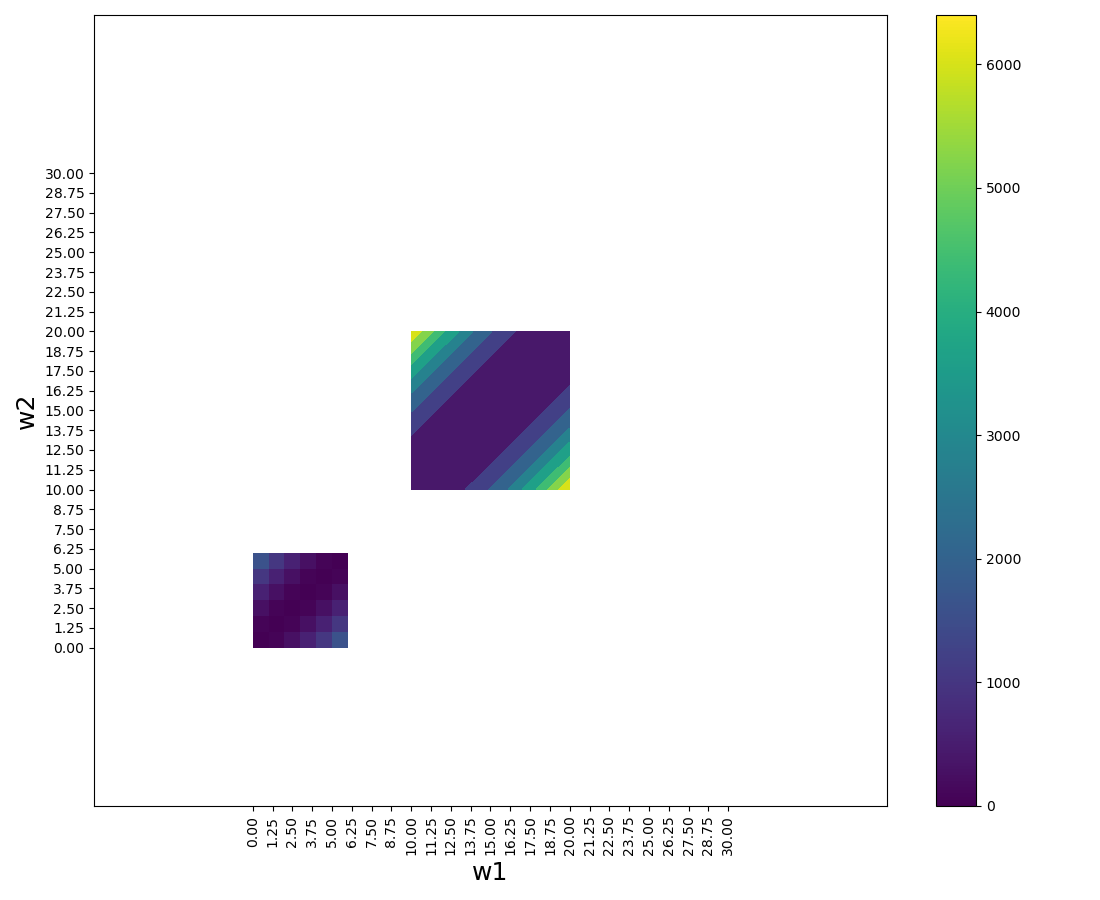

In [218]:
settings = {'el_t2':False, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True
            }
np.set_printoptions(linewidth=100000)
plotspectrum(ranges, data, settings)

In [ ]:
settings = {'el_t2':False, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True
            }
plotspectrum(ranges, data, settings)

In [ ]:
settings = {'el_t2':True, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True
            }
plotspectrum(ranges, data, settings)

In [ ]:
settings = {'el_t2':True, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True
            }
plotspectrum(ranges, data, settings)

In [ ]:
settings = {'el_t2':True, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': True, 'printing': False, 'show_fundamentals': True
            }
plotspectrum(ranges, data, settings)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product

def calculate_sum_on_grid(x_values, y_values):
    results = []
    for x, y in product(x_values, y_values):
        result = x + y
        results.append(result)
    
    return results

def plot_grid(x_values, y_values, z_values):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x_values, y_values, z_values, c=z_values, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()

x_values = [1, 2]
y_values = [5, 6, 7, 8]

sums = calculate_sum_on_grid(x_values, y_values)
plot_grid(x_values * len(y_values), y_values * len(x_values), sums)


In [ ]:
import matplotlib.pyplot as plt
from itertools import product

def calculate_sum_on_grid(x_values, y_values):
    results = []
    print(list(product(x_values, y_values)))
    for x, y in product(x_values, y_values):
        result = x + y
        results.append(result)
    
    return results

def plot_grid(x_values, y_values, z_values):
    fig, ax = plt.subplots()
    cp = ax.scatter(x_values, y_values, c=z_values, cmap='viridis')
    plt.colorbar(cp)
    # cb = plt.colorbar(cp)

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Grid Plot')

    plt.show()

x_values = [1, 2]
y_values = [5, 6, 7, 8]

sums = calculate_sum_on_grid(x_values, y_values)
plot_grid(x_values * len(y_values), y_values * len(x_values), sums)


meshgrid
[[1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]]


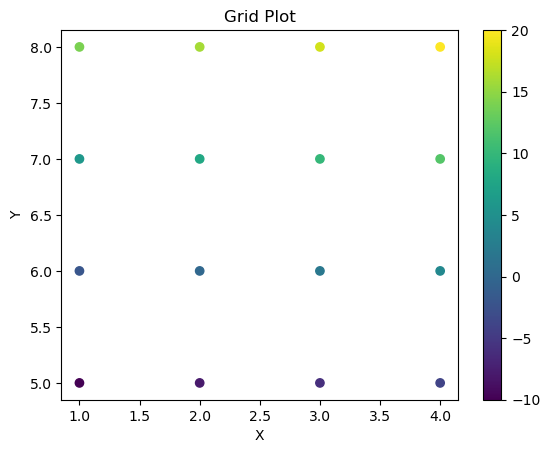

array([[ 6,  7,  8,  9],
       [ 7,  8,  9, 10],
       [ 8,  9, 10, 11],
       [ 9, 10, 11, 12]])

In [54]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from ipywidgets import *

def calculate_sum_on_grid(x_values, y_values):
    results = []
    for x in x_values:
        for y in y_values:
            result = x + y + 2*(x-y)
            results.append(result)
    print('loop')
    print(x_values)
    return results

def sumsum(x, y):
    xx, yy = np.meshgrid(x, y)
    print('meshgrid')
    print(xx)
    return np.array(xx) + np.array(yy) + 2*(np.array(xx)-np.array(yy))

def plot_grid(x_values, y_values, z_values):
    plt.clf()
    x_grid, y_grid = np.meshgrid(x_values, y_values)
    z_grid = np.reshape(z_values, x_grid.shape)

    cp = plt.scatter(x_grid, y_grid, c=np.linspace(-10, 20, len(x_values)*len(y_values)), cmap='viridis')
    plt.colorbar(cp)

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Grid Plot')

    plt.show()


x_values = [1, 2, 3, 4]
y_values = [5, 6, 7, 8]#, 9, 10]

# sums = calculate_sum_on_grid(x_values, y_values)
sums = sumsum(x_values, y_values)
plot_grid(x_values, y_values, sums)
#print(x_values, y_values)
np.array(sums).reshape(len(x_values), len(y_values))

meshgrid
[[1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]]


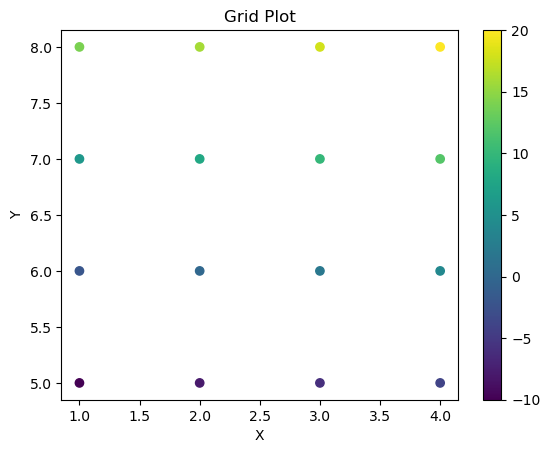

array([[ 6,  7,  8,  9],
       [ 7,  8,  9, 10],
       [ 8,  9, 10, 11],
       [ 9, 10, 11, 12]])

In [56]:
x_values = [1, 2, 3, 4]
y_values = [5, 6, 7, 8]#, 9, 10]

# sums = calculate_sum_on_grid(x_values, y_values)
sums = sumsum(x_values, y_values)
plot_grid(x_values, y_values, sums)
#print(x_values, y_values)
np.array(sums).reshape(len(x_values), len(y_values))

loop
[1, 2, 3, 4]


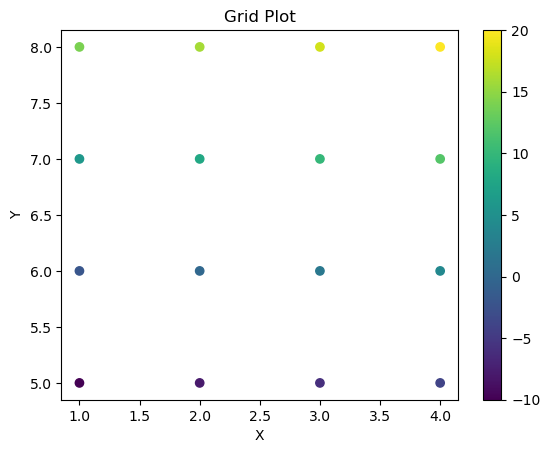

array([[ 6,  7,  8,  9],
       [ 7,  8,  9, 10],
       [ 8,  9, 10, 11],
       [ 9, 10, 11, 12]])

In [57]:
x_values = [1, 2, 3, 4]
y_values = [5, 6, 7, 8]#, 9, 10]

sums = calculate_sum_on_grid(x_values, y_values)
# sums = sumsum(x_values, y_values)
plot_grid(x_values, y_values, sums)
#print(x_values, y_values)
np.array(sums).reshape(len(x_values), len(y_values))

loop
[1, 2, 3, 4]


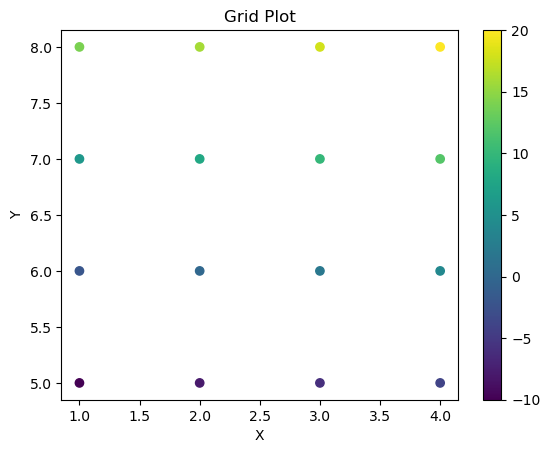

[1, 2, 3, 4] [5, 6, 7, 8]


array([[ 6,  7,  8,  9],
       [ 7,  8,  9, 10],
       [ 8,  9, 10, 11],
       [ 9, 10, 11, 12]])

In [55]:
x_values = [1, 2, 3, 4]
y_values = [5, 6, 7, 8]#, 9, 10]

sums = calculate_sum_on_grid(x_values, y_values)
# sums = sumsum(x_values, y_values)
plot_grid(x_values, y_values, sums)
print(x_values, y_values)
np.array(sums).reshape(len(x_values), len(y_values))

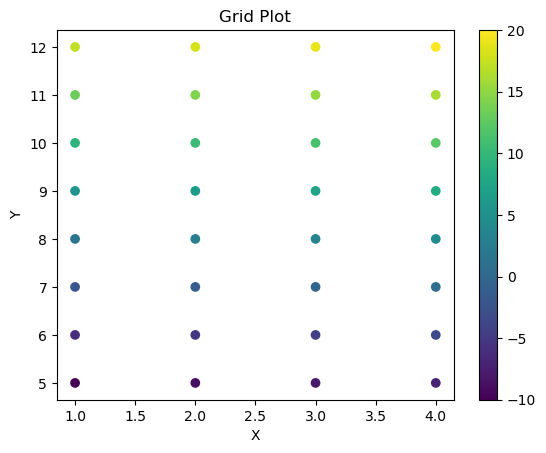

array([[-2, -3, -4, -5, -6, -7, -8, -9],
       [ 1,  0, -1, -2, -3, -4, -5, -6],
       [ 4,  3,  2,  1,  0, -1, -2, -3],
       [ 7,  6,  5,  4,  3,  2,  1,  0]])

In [41]:
x_values = [1, 2, 3, 4]
y_values = [5, 6, 7, 8, 9, 10, 11, 12]

sums = calculate_sum_on_grid(x_values, y_values)
plot_grid(x_values, y_values, sums)
np.array(sums).reshape(len(x_values), len(y_values))

In [82]:
x = [1, 2, 3, 4]
y = [5, 6, 7, 8]#, 9, 10]

xx, yy = np.meshgrid(x, y)
print(xx)
print(yy)
print(xx-yy)

print(list(zip(xx, yy)))
print('----------------')
results = []
for x in x_values:
    results.append([])
    for y in y_values:
        result = x-y
        print(x, y)
        results[x_values.index(x)].append(result)
print(np.array(results).T)
# print(np.array(results).reshape(len(x_values), len(y_values)))

[[1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]]
[[5 5 5 5]
 [6 6 6 6]
 [7 7 7 7]
 [8 8 8 8]]
[[-4 -3 -2 -1]
 [-5 -4 -3 -2]
 [-6 -5 -4 -3]
 [-7 -6 -5 -4]]
[(array([1, 2, 3, 4]), array([5, 5, 5, 5])), (array([1, 2, 3, 4]), array([6, 6, 6, 6])), (array([1, 2, 3, 4]), array([7, 7, 7, 7])), (array([1, 2, 3, 4]), array([8, 8, 8, 8]))]
----------------
1 5
1 6
1 7
1 8
2 5
2 6
2 7
2 8
3 5
3 6
3 7
3 8
4 5
4 6
4 7
4 8
[[-4 -3 -2 -1]
 [-5 -4 -3 -2]
 [-6 -5 -4 -3]
 [-7 -6 -5 -4]]


In [81]:
x = [1, 2, 3, 4]
y = [5, 6, 7, 8, 9, 10]

xx, yy = np.meshgrid(x, y)
print(xx)
print(yy)
print(xx-yy)

print(list(zip(xx, yy)))
print('----------------')
results = []
for i in x:
    results.append([])
    for j in y:
        result = i-j
        print(i, j)
        results[x.index(i)].append(result)
print(np.array(results).T)
# print(np.array(results).reshape(len(x_values), len(y_values)))

[[1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]]
[[ 5  5  5  5]
 [ 6  6  6  6]
 [ 7  7  7  7]
 [ 8  8  8  8]
 [ 9  9  9  9]
 [10 10 10 10]]
[[-4 -3 -2 -1]
 [-5 -4 -3 -2]
 [-6 -5 -4 -3]
 [-7 -6 -5 -4]
 [-8 -7 -6 -5]
 [-9 -8 -7 -6]]
[(array([1, 2, 3, 4]), array([5, 5, 5, 5])), (array([1, 2, 3, 4]), array([6, 6, 6, 6])), (array([1, 2, 3, 4]), array([7, 7, 7, 7])), (array([1, 2, 3, 4]), array([8, 8, 8, 8])), (array([1, 2, 3, 4]), array([9, 9, 9, 9])), (array([1, 2, 3, 4]), array([10, 10, 10, 10]))]
----------------
1 5
1 6
1 7
1 8
1 9
1 10
2 5
2 6
2 7
2 8
2 9
2 10
3 5
3 6
3 7
3 8
3 9
3 10
4 5
4 6
4 7
4 8
4 9
4 10
[[-4 -3 -2 -1]
 [-5 -4 -3 -2]
 [-6 -5 -4 -3]
 [-7 -6 -5 -4]
 [-8 -7 -6 -5]
 [-9 -8 -7 -6]]


In [66]:
import numpy as np
i_coords, j_coords = np.meshgrid(range(5), range(4, 9), indexing='ij')
print(i_coords)
print(j_coords)

coordinate_grid = np.array([i_coords, j_coords])
print(coordinate_grid.shape)
print(coordinate_grid)

print(coordinate_grid[:, 0, 0])
print(coordinate_grid[:, 1, 0])
print(coordinate_grid[:, 0, 1])
print('-----------------------')

coordinate_grid[0, :, :] += 2

print(coordinate_grid[:, 0, 0])
print(coordinate_grid[:, 1, 0])
print(coordinate_grid[:, 0, 1])

[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
[[4 5 6 7 8]
 [4 5 6 7 8]
 [4 5 6 7 8]
 [4 5 6 7 8]
 [4 5 6 7 8]]
(2, 5, 5)
[[[0 0 0 0 0]
  [1 1 1 1 1]
  [2 2 2 2 2]
  [3 3 3 3 3]
  [4 4 4 4 4]]

 [[4 5 6 7 8]
  [4 5 6 7 8]
  [4 5 6 7 8]
  [4 5 6 7 8]
  [4 5 6 7 8]]]
[0 4]
[1 4]
[0 5]
-----------------------
[2 4]
[3 4]
[2 5]


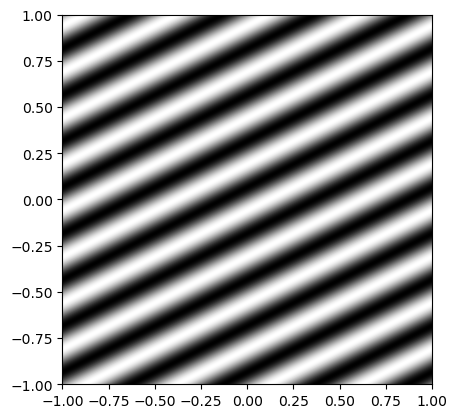

In [67]:
# exploring_meshgrid.py

import matplotlib.pyplot as plt
import numpy as np

wavelength = 0.5
x = y = np.linspace(-1, 1, 1000)

X, Y = np.meshgrid(x, y)

output = np.sin(2 * np.pi * (X + 2 * Y) / wavelength)

plt.imshow(
    output,
    cmap="gray",
    extent=[np.min(x), np.max(x), np.min(y), np.max(y)]
)
plt.show()